<a href="https://colab.research.google.com/github/m4tss0/Calculo-Numerico-2026-2/blob/main/Atividade_1_C%C3%A1lculo_Num%C3%A9rico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 1 - Cálculo Numérico

**Nome:** Mateus de Lima Alencar Soares  
**RA:** 185301  
**Turma:** Noturno  
## Objetivos

- Calcular erros absoluto, relativo e percentual;
- Distinguir truncamento de arredondamento;
- Observar a propagação dos erros em cálculos de pressão e vazão;
- Produzir gráficos que comuniquem a evolução dos erros;
- Explicar por que pequenas variações geométricas podem alterar intensamente o escoamento em um nanocateter.

> **Ideia central:** um resultado numérico deve vir acompanhado de informação sobre sua precisão, suas hipóteses e sua validade.

## Parte A: Truncamento e Arredondamento

Valores considerados: x1 = 3,14159265, x2 = 98,76543, x3 = 0,00498765 (Utilizando n = 0, 1, 2, 3, 4 casas decimais)

1. Calcule a aproximação por truncamento e por arredondamento:
2. calcule Ea, Er e E%
3. organize os resultados em uma tabela
4. faça um gráfico em escala logarítmica de Ea em função de n;
5. responda: arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os
resultados.

In [10]:
import math

# Define uma função para truncar um número em determinada quantidade de casas.
def truncar(numero, casas):
    # Calcula o fator que desloca a vírgula decimal.
    fator = 10 ** casas
    # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

# Define uma função para calcular os três tipos de erro.
def calcula_erros(valor_referencia, valor_aproximado):
    # Calcula a distância entre o valor de referência e a aproximação.
    erro_absoluto = abs(valor_referencia - valor_aproximado)
    # Divide o erro absoluto pelo módulo do valor de referência.
    erro_relativo = erro_absoluto / abs(valor_referencia)
    # Converte o erro relativo em porcentagem.
    erro_percentual = 100.0 * erro_relativo
    return erro_absoluto, erro_relativo, erro_percentual

# Valores de referência dados no enunciado.
valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765,
}

# Casas decimais a testar.
casas_lista = [0, 1, 2, 3, 4]

# Percorre cada valor de referência.
for nome_x, x_ref in valores.items():
    # Exibe um cabeçalho para separar visualmente cada valor.
    print(f"\n{'='*50}")
    print(f"Valor de referência {nome_x} = {x_ref}")
    print(f"{'='*50}")

    # Percorre cada quantidade de casas decimais.
    for n in casas_lista:
        # Calcula a aproximação por truncamento.
        x_trunc = truncar(x_ref, n)
        # Calcula a aproximação por arredondamento.
        x_round = round(x_ref, n)

        # Calcula os três erros para o truncamento.
        ea_t, er_t, ep_t = calcula_erros(x_ref, x_trunc)
        # Calcula os três erros para o arredondamento.
        ea_r, er_r, ep_r = calcula_erros(x_ref, x_round)

        # Exibe os resultados de forma legível para esse n.
        print(f"\n--- n = {n} casas decimais ---")
        print(f"Truncado:      {x_trunc}")
        print(f"  Ea = {ea_t:.10f}   Er = {er_t:.6e}   E% = {ep_t:.6f}%")
        print(f"Arredondado:   {x_round}")
        print(f"  Ea = {ea_r:.10f}   Er = {er_r:.6e}   E% = {ep_r:.6f}%")


Valor de referência x1 = 3.14159265

--- n = 0 casas decimais ---
Truncado:      3.0
  Ea = 0.1415926500   Er = 4.507034e-02   E% = 4.507034%
Arredondado:   3.0
  Ea = 0.1415926500   Er = 4.507034e-02   E% = 4.507034%

--- n = 1 casas decimais ---
Truncado:      3.1
  Ea = 0.0415926500   Er = 1.323935e-02   E% = 1.323935%
Arredondado:   3.1
  Ea = 0.0415926500   Er = 1.323935e-02   E% = 1.323935%

--- n = 2 casas decimais ---
Truncado:      3.14
  Ea = 0.0015926500   Er = 5.069562e-04   E% = 0.050696%
Arredondado:   3.14
  Ea = 0.0015926500   Er = 5.069562e-04   E% = 0.050696%

--- n = 3 casas decimais ---
Truncado:      3.141
  Ea = 0.0005926500   Er = 1.886464e-04   E% = 0.018865%
Arredondado:   3.142
  Ea = 0.0004073500   Er = 1.296635e-04   E% = 0.012966%

--- n = 4 casas decimais ---
Truncado:      3.1415
  Ea = 0.0000926500   Er = 2.949141e-05   E% = 0.002949%
Arredondado:   3.1416
  Ea = 0.0000073500   Er = 2.339578e-06   E% = 0.000234%

Valor de referência x2 = 98.76543

--- n

In [11]:
# Solução - Tópico 3:

# Lista que vai acumular uma linha por combinação (valor, n).
linhas = []

# Percorre cada valor de referência.
for nome_x, x_ref in valores.items():
    # Percorre cada quantidade de casas decimais.
    for n in casas_lista:
        # Calcula a aproximação por truncamento.
        x_trunc = truncar(x_ref, n)
        # Calcula a aproximação por arredondamento.
        x_round = round(x_ref, n)

        # Calcula os três erros para o truncamento.
        ea_t, er_t, ep_t = calcula_erros(x_ref, x_trunc)
        # Calcula os três erros para o arredondamento.
        ea_r, er_r, ep_r = calcula_erros(x_ref, x_round)

        # Adiciona a linha do truncamento.
        linhas.append({
            "valor": nome_x, "x_ref": x_ref, "n": n, "metodo": "truncamento",
            "aproximacao": x_trunc, "Ea": ea_t, "Er": er_t, "E%": ep_t
        })
        # Adiciona a linha do arredondamento.
        linhas.append({
            "valor": nome_x, "x_ref": x_ref, "n": n, "metodo": "arredondamento",
            "aproximacao": x_round, "Ea": ea_r, "Er": er_r, "E%": ep_r
        })

# Monta o DataFrame com todas as linhas.
tabela = pd.DataFrame(linhas)

# Exibe a tabela completa, formatada.
tabela.style.format({
    "x_ref": "{:.8f}", "aproximacao": "{:.8f}",
    "Ea": "{:.10f}", "Er": "{:.6e}", "E%": "{:.6f}"
})

,valor,x_ref,n,metodo,aproximacao,Ea,Er,E%
0,x1,3.14159265,0,truncamento,3.00000000,0.1415926500,4.507034e-02,4.507034
1,x1,3.14159265,0,arredondamento,3.00000000,0.1415926500,4.507034e-02,4.507034
2,x1,3.14159265,1,truncamento,3.10000000,0.0415926500,1.323935e-02,1.323935
3,x1,3.14159265,1,arredondamento,3.10000000,0.0415926500,1.323935e-02,1.323935
4,x1,3.14159265,2,truncamento,3.14000000,0.0015926500,5.069562e-04,0.050696
5,x1,3.14159265,2,arredondamento,3.14000000,0.0015926500,5.069562e-04,0.050696
6,x1,3.14159265,3,truncamento,3.14100000,0.0005926500,1.886464e-04,0.018865
7,x1,3.14159265,3,arredondamento,3.14200000,0.0004073500,1.296635e-04,0.012966
8,x1,3.14159265,4,truncamento,3.14150000,0.0000926500,2.949141e-05,0.002949
9,x1,3.14159265,4,arredondamento,3.14160000,0.0000073500,2.339578e-06,0.000234


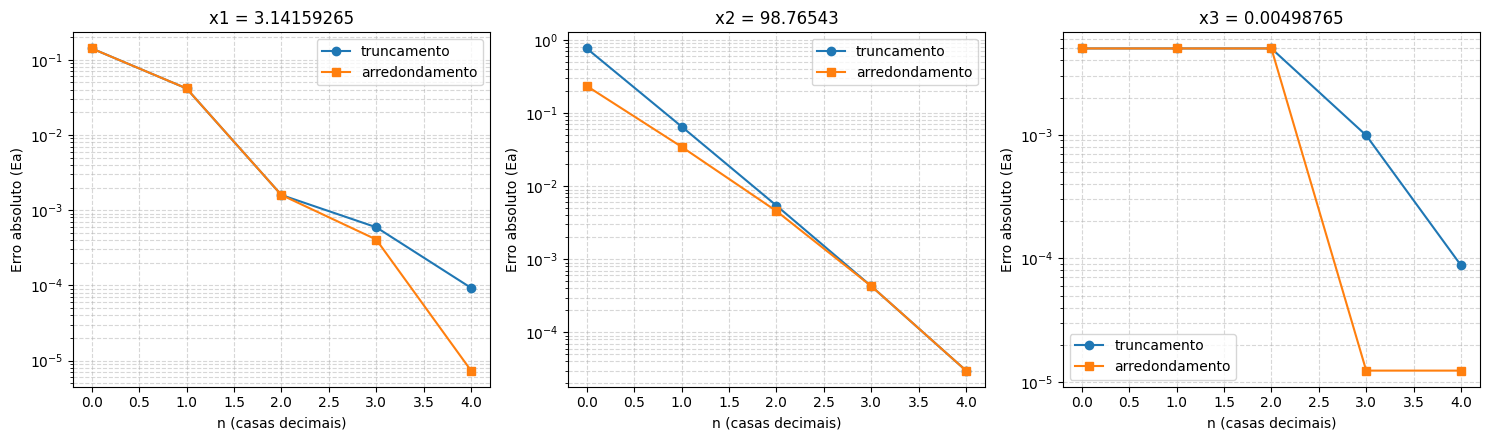

In [12]:
# Solução - Tópico 4:

# Cria uma figura com um subplot por valor de referência.
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))

# Percorre cada valor de referência junto com seu eixo correspondente.
for eixo, nome_x in zip(eixos, valores):
    # Filtra a tabela para o valor atual.
    dados_x = tabela[tabela["valor"] == nome_x]

    # Separa os dados de truncamento e arredondamento.
    trunc = dados_x[dados_x["metodo"] == "truncamento"]
    round_ = dados_x[dados_x["metodo"] == "arredondamento"]

    # Plota Ea (truncamento) em função de n.
    eixo.plot(trunc["n"], trunc["Ea"], marker="o", label="truncamento")
    # Plota Ea (arredondamento) em função de n.
    eixo.plot(round_["n"], round_["Ea"], marker="s", label="arredondamento")

    # Ea pode ser zero (ex.: n=4 em x3), então soma um valor mínimo antes do log.
    eixo.set_yscale("log")
    eixo.set_xlabel("n (casas decimais)")
    eixo.set_ylabel("Erro absoluto (Ea)")
    eixo.set_title(f"{nome_x} = {valores[nome_x]}")
    eixo.legend()
    eixo.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Resposta Tópico 5:
  A partir da tabela de referência obtida na solução do tópico 3, nota-se que o arredondamento sempre gera um erro menor ou igual ao erro gerado pelo truncamento dos valores analisados.


## Parte B: Medidas de Pressão Arterial

Registro de dez medidas consecutivas de pressão arterial sistólica, em mmHg:
121,7; 120,4; 122,1; 119,8; 121,2; 120,9; 122,4; 121,0; 120,2; 121,5.

(Considerando como referência a média calculada com todos os algarismos disponíveis)


#### B.1 - Representação das medidas
Três séries:
1. dados originais;
2. dados arredondados para o inteiro mais próximo;
3. dados truncados para números inteiros.

In [13]:
import numpy as np
import pandas as pd

# Reaproveita a função de truncamento já definida.
def truncar(numero, casas):
    fator = 10 ** casas
    return math.trunc(numero * fator) / fator

# Dados originais registrados pelo equipamento (mmHg).
dados_originais = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

# Série 2: dados arredondados para o inteiro mais próximo.
dados_arredondados = [round(x, 0) for x in dados_originais]

# Série 3: dados truncados para números inteiros.
dados_truncados = [truncar(x, 0) for x in dados_originais]

# Referência: média calculada com todos os algarismos disponíveis (dados originais).
media_referencia = np.mean(dados_originais)

# Organiza as três séries em um dicionário para facilitar o loop.
series = {
    "originais": dados_originais,
    "arredondados": dados_arredondados,
    "truncados": dados_truncados,
}

# Lista que vai acumular uma linha de estatísticas por série.
linhas_stats = []

# Percorre cada série calculando as estatísticas pedidas.
for nome_serie, valores_serie in series.items():
    media = np.mean(valores_serie)
    minimo = np.min(valores_serie)
    maximo = np.max(valores_serie)
    amplitude = maximo - minimo
    # ddof=1 para desvio-padrão AMOSTRAL (divide por n-1).
    desvio_padrao = np.std(valores_serie, ddof=1)

    # Calcula os três erros da média da série em relação à média de referência.
    erro_absoluto = abs(media_referencia - media)
    erro_relativo = erro_absoluto / abs(media_referencia)
    erro_percentual = 100.0 * erro_relativo

    linhas_stats.append({
        "serie": nome_serie,
        "media": media,
        "minimo": minimo,
        "maximo": maximo,
        "amplitude": amplitude,
        "desvio_padrao": desvio_padrao,
        "Ea_media": erro_absoluto,
        "Er_media": erro_relativo,
        "E%_media": erro_percentual,
    })

# Monta a tabela final com as estatísticas de cada série.
tabela_b1 = pd.DataFrame(linhas_stats)

# Exibe a tabela formatada.
tabela_b1.style.format({
    "media": "{:.4f}", "minimo": "{:.1f}", "maximo": "{:.1f}",
    "amplitude": "{:.1f}", "desvio_padrao": "{:.4f}",
    "Ea_media": "{:.6f}", "Er_media": "{:.6e}", "E%_media": "{:.6f}"
})

,serie,media,minimo,maximo,amplitude,desvio_padrao,Ea_media,Er_media,E%_media
0,originais,121.1200,119.8,122.4,2.6,0.8337,0.000000,0.000000e+00,0.000000
1,arredondados,121.1000,120.0,122.0,2.0,0.8756,0.020000,1.651255e-04,0.016513
2,truncados,120.7000,119.0,122.0,3.0,0.9487,0.420000,3.467635e-03,0.346764


#### B.2 - Gráficos
1. gráfico das dez medições, mostrando as três séries;
2. gráfico de barras dos erros absolutos das médias;
3. gráfico de barras dos erros percentuais das médias;
4. histograma dos dados originais e dos dados inteiros arredondados.

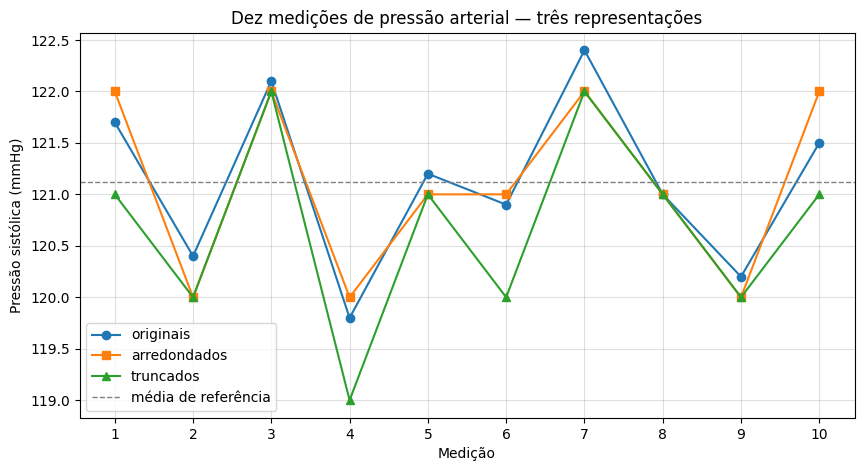

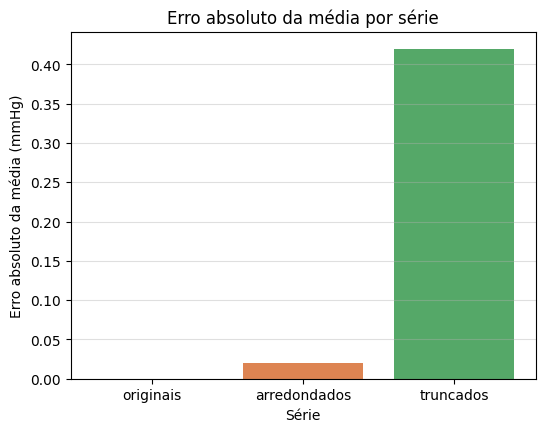

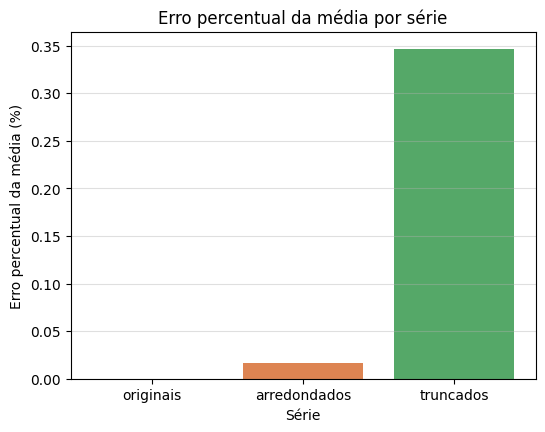

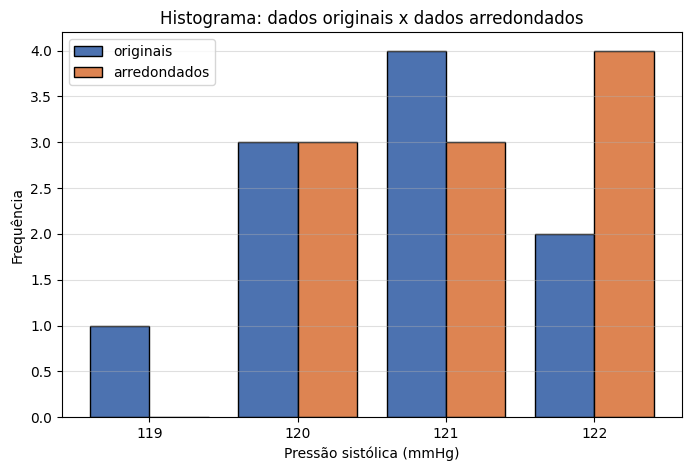

In [16]:
import matplotlib.pyplot as plt

# Eixo x: número da medição (1 a 10).
medicoes = list(range(1, 11))

# Cria a figura.
plt.figure(figsize=(10, 5))

# Plota a série de dados originais.
plt.plot(medicoes, dados_originais, marker="o", label="originais")
# Plota a série de dados arredondados.
plt.plot(medicoes, dados_arredondados, marker="s", label="arredondados")
# Plota a série de dados truncados.
plt.plot(medicoes, dados_truncados, marker="^", label="truncados")

# Adiciona uma linha horizontal com a média de referência, para contexto.
plt.axhline(media_referencia, color="gray", linestyle="--", linewidth=1, label="média de referência")

plt.xlabel("Medição")
plt.ylabel("Pressão sistólica (mmHg)")
plt.title("Dez medições de pressão arterial — três representações")
plt.xticks(medicoes)
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

plt.figure(figsize=(6, 4.5))

# Usa a tabela do B.1 diretamente (colunas 'serie' e 'Ea_media').
plt.bar(tabela_b1["serie"], tabela_b1["Ea_media"], color=["#4C72B0", "#DD8452", "#55A868"])

plt.xlabel("Série")
plt.ylabel("Erro absoluto da média (mmHg)")
plt.title("Erro absoluto da média por série")
plt.grid(True, axis="y", alpha=0.4)
plt.show()

plt.figure(figsize=(6, 4.5))

# Mesma lógica, agora usando a coluna 'E%_media'.
plt.bar(tabela_b1["serie"], tabela_b1["E%_media"], color=["#4C72B0", "#DD8452", "#55A868"])

plt.xlabel("Série")
plt.ylabel("Erro percentual da média (%)")
plt.title("Erro percentual da média por série")
plt.grid(True, axis="y", alpha=0.4)
plt.show()

plt.figure(figsize=(8, 5))

# Define os bins compartilhados.
bins = np.arange(119, 124, 1)

# Calcula a contagem de cada série em cada bin, sem plotar ainda.
contagem_original, _ = np.histogram(dados_originais, bins=bins)
contagem_arredondado, _ = np.histogram(dados_arredondados, bins=bins)

# Centro de cada bin e largura de cada barra individual.
centros_bins = bins[:-1]
largura_barra = 0.4

# Plota as barras dos originais, deslocadas para a esquerda do centro do bin.
plt.bar(centros_bins - largura_barra/2, contagem_original, width=largura_barra,
        label="originais", color="#4C72B0", edgecolor="black")

# Plota as barras dos arredondados, deslocadas para a direita do centro do bin.
plt.bar(centros_bins + largura_barra/2, contagem_arredondado, width=largura_barra,
        label="arredondados", color="#DD8452", edgecolor="black")

plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Frequência")
plt.title("Histograma: dados originais x dados arredondados")
plt.xticks(centros_bins)
plt.legend()
plt.grid(True, axis="y", alpha=0.4)
plt.show()